# Power Test: Can We Detect XX% Change in Cell-Type Composition?

For a given cell type, effect size, and embryo count, this notebook estimates statistical power by:
1. Simulating WT and mutant embryo cohorts from a Dirichlet model fit to real data.
2. Applying a proportional reduction to the target cell type in the mutant cohort.
3. Running the Hooke `compare_abundances` regression.
4. Recording whether the target cell type is detected (q-value < threshold).
5. Sweeping over effect sizes and embryo counts to produce a power curve.

## Setup

In [1]:
library(monocle3)
library(dplyr)
library(tidyr)
library(hooke)
library(tibble)
library(ggplot2)
dyn.load("/net/gs/vol3/software/modules-sw/hdf5/1.14.3/Linux/Ubuntu22.04/x86_64/lib/libhdf5.so.310")
library(BPCells)

Loading required package: Biobase

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, table,
    tapply, union, unique, unsplit, which.max, which.min


Welcome to Bioconductor

    Vignettes contain introductory material; view with
    'browseVignettes()'. To cite Bioconductor, see
    'citation("Biobase")', and for packages 'citation("pkgname")'.


Loading required package: SingleCellExperiment

Loading required package: SummarizedExperiment

Loading required package: MatrixGenerics

Loading requi

## Load Real Data (used only to fit the Dirichlet model)

In [2]:
temp_path    <- "/net/trapnell/vol1/home/nlammers/tmp_files/nobackup/"
seahub_root  <- "/net/seahub_zfish/vol1/data/annotated/v2.2.0/"
ct_path      <- "/net/trapnell/vol1/home/elizab9/projects/projects/CHEMFISH/resources/unique_ct_full.csv"
dataset_name <- "REF1"

cds_path <- file.path(seahub_root, dataset_name, paste0(dataset_name, "_projected_cds_v2.2.0/"))
cds <- load_monocle_objects(
  cds_path,
  matrix_control = list(matrix_class = "BPCells", matrix_path = temp_path)
)

# Attach broad cell type labels if missing
ct_broad <- read.csv(ct_path)
ct_broad_filt <- ct_broad %>%
  count(cell_type, cell_type_broad) %>%
  group_by(cell_type) %>%
  slice_max(n, with_ties = FALSE) %>%
  ungroup() %>%
  select(cell_type, cell_type_broad)

md <- as.data.frame(colData(cds))
if (!("cell_type_broad" %in% colnames(md)) && "cell_type" %in% colnames(md)) {
  md <- md %>% left_join(ct_broad_filt, by = "cell_type")
  colData(cds)$cell_type_broad <- md$cell_type_broad
}

# Build the embryo-level cell count set from WT/control embryos only
ctrl_labels <- c("EtOH", "DMSO", "ctrl-inj", "reference", "ctrl-uninj", "novehicle")
keep_cells  <- md %>%
  filter(!is.na(cell_type_broad)) %>%
  filter(is.na(perturbation) | perturbation %in% ctrl_labels) %>%
  rownames(.)

cds_ctrl <- cds[, keep_cells]

ccs_spec <- new_cell_count_set(
  cds_ctrl,
  sample_group = "embryo_ID",
  cell_group   = "cell_type"
)

ccs <- new_cell_count_set(
  cds_ctrl,
  sample_group = "embryo_ID",
  cell_group   = "cell_type_broad"
)

ccs_spec <- ccs_spec[, !is.na(ccs_spec$timepoint)]
ccs <- ccs[, !is.na(ccs$timepoint)]

cat("Cell types available:\n")
print(rownames(counts(ccs)))

1 NAs found in cell group. Dropping NAs.

Warning message in monocle3::new_cell_data_set(cell_counts_wide, cell_metadata = cds_covariates_df, :
“gene_metadata must contain a column verbatim named 'gene_short_name' for certain functions.”
Warning message in monocle3::new_cell_data_set(cell_counts_wide, cell_metadata = cds_covariates_df, :
“gene_metadata must contain a column verbatim named 'gene_short_name' for certain functions.”


Cell types available:
  [1] "adenohypophysis"                                                                       
  [2] "adrenal gland"                                                                         
  [3] "anterior eye"                                                                          
  [4] "apical ectodermal ridge"                                                               
  [5] "basal cell"                                                                            
  [6] "cardiomyocyte"                                                                         
  [7] "chondrocranium"                                                                        
  [8] "connective tissue-meninges-dermal FB, early"                                           
  [9] "connective tissue-meninges-dermal FB, late"                                            
 [10] "corpuscles of stannius"                                                                
 [11] "cranial ganglion prog

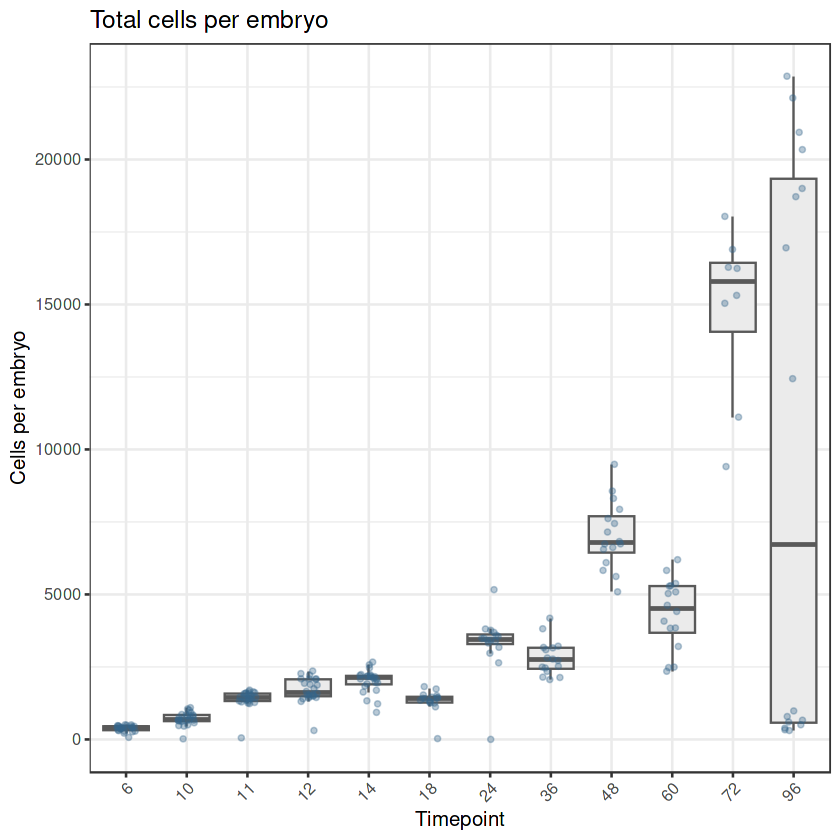

In [45]:
cell_count_boxplot_df <- counts(ccs) %>%
  as.matrix() %>%
  as.data.frame() %>%
  colSums() %>%
  enframe(name = "embryo", value = "total_cells") %>%
  dplyr::left_join(
    as.data.frame(colData(ccs)) %>%
      tibble::rownames_to_column("embryo") %>%
      dplyr::select(embryo, timepoint),
    by = "embryo"
  ) %>%
  dplyr::mutate(timepoint = factor(timepoint, levels = sort(unique(timepoint))))

ggplot(cell_count_boxplot_df, aes(x = timepoint, y = total_cells)) +
  geom_boxplot(outlier.shape = NA, fill = "grey92", color = "grey35") +
  geom_jitter(width = 0.15, alpha = 0.35, size = 1.1, color = "steelblue4") +
  labs(
    title = "Total cells per embryo",
    x = "Timepoint",
    y = "Cells per embryo"
  ) +
  theme_bw(base_size = 12) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

In [47]:
cell_count_boxplot_df %>%
  group_by(timepoint) %>%
  summarise(
    mean_cells = mean(total_cells),
    median_cells = median(total_cells),
    n_embryos = n()
  )

timepoint,mean_cells,median_cells,n_embryos
<fct>,<dbl>,<dbl>,<int>
6,380.6667,409.0,24
10,712.7917,678.0,24
11,1399.8750,1434.5,24
12,1703.7917,1624.5,24
14,2006.2917,2123.0,24
18,1335.5000,1408.0,16
24,3307.6875,3456.5,16
36,2819.6875,2746.5,16
48,7039.9375,6784.0,16


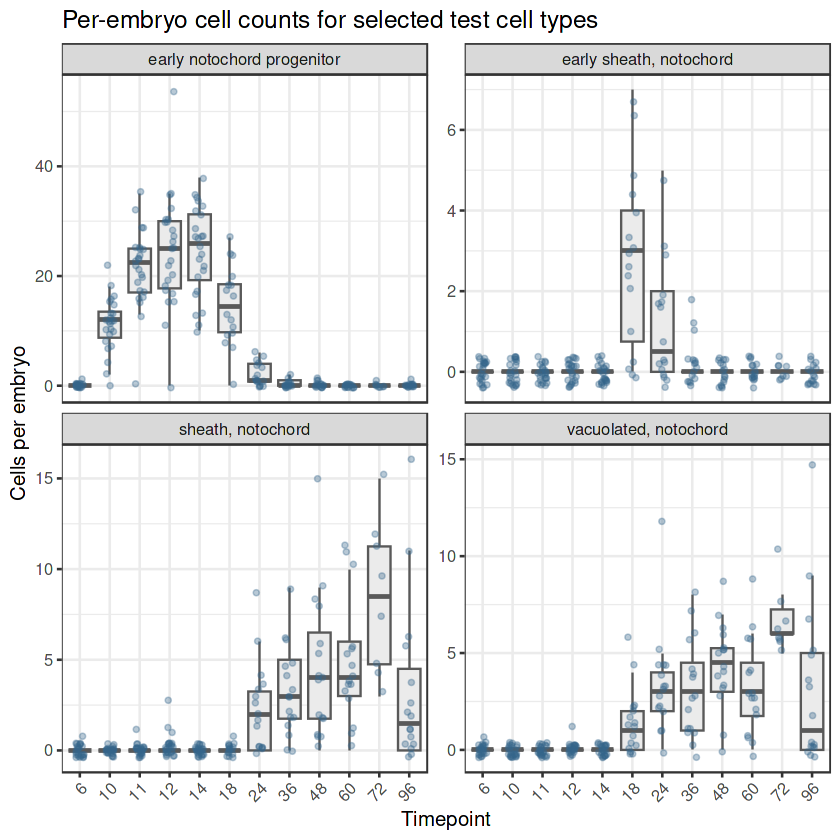

In [5]:
# target_cell_types <- c('early notochord','early notochord progenitor','late vacuolated notochord','late notochord sheath','early notochord sheath','early vacuolated notochord','late notochord sheath, proliferative','late notochord sheath (entpd5a+)')   # cell type(s) to reduce in the MT ar 'unknown 1 (notochord, suspected doublets)'
cells_to_test <- target_cell_types

cell_count_boxplot_df <- counts(ccs) %>%
  as.matrix() %>%
  as.data.frame() %>%
  tibble::rownames_to_column("cell_group") %>%
  tidyr::pivot_longer(
    -cell_group,
    names_to = "embryo",
    values_to = "cell_count"
  ) %>%
  dplyr::filter(cell_group %in% cells_to_test) %>%
  dplyr::left_join(
    as.data.frame(colData(ccs)) %>%
      tibble::rownames_to_column("embryo") %>%
      dplyr::select(embryo, timepoint),
    by = "embryo"
  ) %>%
  dplyr::mutate(
    timepoint = factor(timepoint, levels = sort(unique(timepoint)))
  )

ggplot(cell_count_boxplot_df, aes(x = timepoint, y = cell_count)) +
  geom_boxplot(outlier.shape = NA, fill = "grey92", color = "grey35") +
  geom_jitter(width = 0.15, alpha = 0.35, size = 1.1, color = "steelblue4") +
  facet_wrap(~ cell_group, scales = "free_y") +
  labs(
    title = "Per-embryo cell counts for selected test cell types",
    x = "Timepoint",
    y = "Cells per embryo"
  ) +
  theme_bw(base_size = 12) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

## Helper Functions (from interactive notebook)

In [25]:
## ============================================================================
## Simulation functions — plain R, no monocle3 wrapping
## ============================================================================
## Each simulate_* function returns a list with:
##   $counts    — matrix (cell_types x embryos)
##   $col_data  — data.frame (one row per embryo)

get_cell_count_wide <- function(ccs) {
  counts(ccs) %>% as.matrix() %>% as.data.frame()
}

get_timepoint_levels <- function(ccs, timepoint_col = "timepoint", timepoints = NULL) {
  md <- as.data.frame(colData(ccs))
  available <- sort(unique(as.character(md[[timepoint_col]])))
  available <- available[!is.na(available) & nzchar(available)]
  if (is.null(timepoints)) return(available)
  missing <- setdiff(timepoints, available)
  if (length(missing) > 0)
    stop(sprintf("Timepoint(s) not found: %s", paste(missing, collapse = ", ")))
  available[available %in% timepoints]
}

subset_ccs_by_timepoint <- function(ccs, timepoint_value, timepoint_col = "timepoint") {
  md <- as.data.frame(colData(ccs))
  keep <- rownames(md)[as.character(md[[timepoint_col]]) == as.character(timepoint_value)]
  ccs[, keep]
}

get_prop_mat <- function(cell_count_wide, pseudocount = 1) {
  cell_count_wide %>%
    tibble::rownames_to_column("cell_group") %>%
    tidyr::pivot_longer(-cell_group, names_to = "embryo", values_to = "count") %>%
    dplyr::mutate(count = count + pseudocount) %>%
    dplyr::group_by(embryo) %>%
    dplyr::mutate(prop = count / sum(count)) %>%
    dplyr::select(-count) %>%
    tidyr::pivot_wider(names_from = cell_group, values_from = prop) %>%
    tibble::column_to_rownames("embryo") %>%
    as.matrix()
}

fit_drichlet <- function(prop_mat, model_formula_str = "~ 1", trace = FALSE) {
  model_formula <- as.formula(paste("prop_mat", model_formula_str))
  VGAM::vglm(model_formula, data = as.data.frame(prop_mat),
              family = "dirichlet", trace = trace)
}

simulate_single_timepoint <- function(ccs, embryo_size = 1000, random.seed = 111,
                                      genotype = "WT", num_embryos = NULL,
                                      timepoint_value = NULL) {
  cell_count_wide <- get_cell_count_wide(ccs)
  prop_mat <- get_prop_mat(cell_count_wide)
  dfit <- fit_drichlet(prop_mat)

  if (is.null(num_embryos)) num_embryos <- ncol(cell_count_wide)
  num_sims <- ceiling(num_embryos / ncol(cell_count_wide))

  n_obs <- nrow(prop_mat)
  n_types <- ncol(prop_mat)
  dsim <- VGAM::simulate.vlm(dfit, nsim = num_sims, seed = random.seed)
  if (!is.list(dsim)) dsim <- list(dsim)
  dsim <- lapply(dsim, function(d) {
    d <- matrix(d, nrow = n_obs, ncol = n_types, byrow = FALSE)
    colnames(d) <- colnames(prop_mat)
    d
  })
  
  sim_prop_wide <- dplyr::bind_rows(lapply(dsim, as.data.frame))
  sim_prop_wide <- sim_prop_wide[seq_len(num_embryos), , drop = FALSE]
  sim_prop_wide$embryo <- seq_len(nrow(sim_prop_wide))

  total_cells <- rpois(n = num_embryos, lambda = embryo_size)

  sim_count_wide <- sim_prop_wide %>%
    tidyr::pivot_longer(-embryo, names_to = "cell_group", values_to = "cell_prop") %>%
    dplyr::left_join(data.frame(embryo = seq_len(num_embryos),
                                total_cells = total_cells), by = "embryo") %>%
    dplyr::mutate(count = round(total_cells * cell_prop)) %>%
    dplyr::select(-c(total_cells, cell_prop)) %>%
    tidyr::pivot_wider(names_from = "embryo", values_from = count) %>%
    tibble::column_to_rownames("cell_group") %>%
    as.matrix()

  tp_tag <- if (is.null(timepoint_value)) "all" else as.character(timepoint_value)
  colnames(sim_count_wide) <- paste0("embryo-", genotype, "-", tp_tag, "-",
                                      seq_len(ncol(sim_count_wide)))

  col_data <- data.frame(
    embryo      = colnames(sim_count_wide),
    genotype    = genotype,
    timepoint   = tp_tag,
    embryo_size = embryo_size,
    stringsAsFactors = FALSE
  )
  rownames(col_data) <- col_data$embryo

  list(counts = sim_count_wide, col_data = col_data)
}

simulate_embryos <- function(ccs, embryo_size = 1000, random.seed = 111,
                             genotype = "WT", num_embryos = 10,
                             timepoints = NULL, timepoint_col = "timepoint") {
  selected_timepoints <- get_timepoint_levels(ccs, timepoint_col, timepoints)

  parts <- lapply(seq_along(selected_timepoints), function(i) {
    tp <- selected_timepoints[i]
    suppressWarnings(
      simulate_single_timepoint(
        subset_ccs_by_timepoint(ccs, tp, timepoint_col),
        embryo_size = embryo_size,
        random.seed = random.seed + i * 1000,
        genotype    = genotype,
        num_embryos = num_embryos,
        timepoint_value = tp
      )
    )
  })

  list(
    counts   = do.call(cbind, lapply(parts, `[[`, "counts")),
    col_data = dplyr::bind_rows(lapply(parts, `[[`, "col_data"))
  )
}

mutate_counts <- function(sim, cell_types, effect_size) {
  mat <- sim$counts
  for (ct in cell_types) {
    if (ct %in% rownames(mat)) {
      mat[ct, ] <- round(mat[ct, ] * (1 - effect_size))
    }
  }
  sim$counts <- mat
  sim$col_data$mutated <- TRUE
  sim$col_data$effect_size <- effect_size
  sim
}

combine_sims <- function(sim_list) {
  list(
    counts   = do.call(cbind, lapply(sim_list, `[[`, "counts")),
    col_data = dplyr::bind_rows(lapply(sim_list, `[[`, "col_data"))
  )
}

## Power Test Parameters

Edit these before running the sweep.

| Parameter | Meaning |
|---|---|
| `target_cell_types` | Cell type(s) to perturb — must match names in `rownames(counts(ccs))` |
| `sim_timepoints` | Optional subset of timepoints to simulate; `NULL` uses all observed timepoints |
| `timepoint_col` | Column in `colData(ccs)` that defines developmental stage |
| `effect_sizes` | Fractional reduction in the target cell type (0.2 = 20% fewer cells) |
| `embryo_counts` | Number of embryos per genotype arm per timepoint |
| `embryo_size` | Mean total cells per simulated embryo |
| `extra_cell_type_bootstrap_n` | Number of additional random cell types to perturb alongside `target_cell_types` |
| `n_sim` | Simulations per (effect_size × n_embryos) combination |
| `q_threshold` | FDR threshold for calling a hit |
| `num_threads` | Parallelism passed to `new_cell_count_model` |
| `vhat_method` | Hooke variance estimator passed to `new_cell_count_model` |

In [48]:
1-effect_sizes

[1] 0.875 0.750 0.500 0.290

In [61]:
# ------------------------------------------------------------------
# USER-EDITABLE PARAMETERS
# ------------------------------------------------------------------
# target_cell_types <- c('early notochord','early notochord progenitor','late vacuolated notochord','late notochord sheath',,'early notochord sheath','early vacuolated notochord','late notochord sheath, proliferative','late notochord sheath (entpd5a+)')   # cell type(s) to reduce in the MT ar 'unknown 1 (notochord, suspected doublets)'m
sim_timepoints    <- c(24, 36); # NULL uses all observed timepoints
timepoint_col     <- "timepoint"
effect_sizes      <- c(0.75, 0.50, .25)  # fractional reductions to sweep
embryo_counts     <- c(8, 16, 24, 32)             # embryos per arm to sweep
embryo_size       <- 3000   # mean cells per embryo (Poisson)
extra_cell_type_bootstrap_n <- 0  # additional random cell types to perturb each trial
n_sim             <- 25    # simulations per grid cell
q_threshold       <- 0.05   # FDR cutoff for detection
num_threads       <- 4
vhat_method       <- "bootstrap"
base_seed         <- 42
# ------------------------------------------------------------------

## Run Power Sweep (fast version)

In [62]:
# wt <- simulate_embryos(ccs, embryo_size = 1000, random.seed = 42,
#                         genotype = "WT", num_embryos = 5,
#                         timepoints = sim_timepoints, timepoint_col = timepoint_col)
# cat("dim:", dim(wt$counts), "\n")
# print(rownames(wt$counts)[1:5])

In [63]:
## ============================================================================
## NB GLM power analysis — uses simulation_functions_v2.R
## ============================================================================

library(MASS)

extract_timepoint_effects <- function(fit, timepoint_levels, timepoint_col) {
  coefs <- coef(fit)
  vcov_m <- vcov(fit)
  geno <- "genotypeMT"

  dplyr::bind_rows(lapply(timepoint_levels, function(tp) {
    int_term <- intersect(
      c(paste0("genotypeMT:", timepoint_col, tp),
        paste0(timepoint_col, tp, ":genotypeMT")),
      names(coefs)
    )
    terms_used <- c(geno, int_term)
    if (!all(terms_used %in% names(coefs)))
      return(tibble::tibble(timepoint = tp, estimated_effect = NA_real_,
                            std_error = NA_real_, p_value = NA_real_))
    est <- sum(coefs[terms_used])
    se  <- sqrt(sum(vcov_m[terms_used, terms_used]))
    tibble::tibble(timepoint = tp, estimated_effect = unname(est),
                   std_error = unname(se),
                   p_value = 2 * pnorm(abs(est / se), lower.tail = FALSE))
  }))
}

run_trial_nb <- function(ccs, target_cell_types, effect_size, num_embryos,
                         embryo_size, seed, q_threshold,
                         timepoints = NULL, timepoint_col = "timepoint") {

  selected_timepoints <- get_timepoint_levels(ccs, timepoint_col, timepoints)

  wt <- simulate_embryos(ccs, embryo_size = embryo_size, random.seed = seed,
                          genotype = "WT", num_embryos = num_embryos,
                          timepoints = selected_timepoints, timepoint_col = timepoint_col)

  mt <- simulate_embryos(ccs, embryo_size = embryo_size, random.seed = seed + 1e6,
                          genotype = "MT", num_embryos = num_embryos,
                          timepoints = selected_timepoints, timepoint_col = timepoint_col)
  mt <- mutate_counts(mt, target_cell_types, effect_size)

  combined <- combine_sims(list(wt, mt))
  count_mat <- combined$counts
  col_data  <- combined$col_data
  col_data$log_total  <- log(pmax(colSums(count_mat), 1))
  col_data$genotype   <- factor(col_data$genotype, levels = c("WT", "MT"))
  col_data[[timepoint_col]] <- factor(col_data$timepoint)

  fml <- as.formula(sprintf("count ~ genotype * %s + offset(log_total)", timepoint_col))

  result <- dplyr::bind_rows(lapply(rownames(count_mat), function(ct) {
    col_data$count <- as.numeric(count_mat[ct, ])
    fit <- tryCatch(suppressWarnings(MASS::glm.nb(fml, data = col_data)),
                    error = function(e) NULL)
    if (is.null(fit)) {
      return(tidyr::expand_grid(timepoint = selected_timepoints) %>%
        dplyr::mutate(cell_group = ct, estimated_effect = NA_real_,
                      std_error = NA_real_, p_value = NA_real_,
                      model_converged = FALSE))
    }
    extract_timepoint_effects(fit, selected_timepoints, timepoint_col) %>%
      dplyr::mutate(cell_group = ct, model_converged = TRUE)
  }))

  result %>%
    dplyr::mutate(
      is_target   = cell_group %in% target_cell_types,
      true_effect = ifelse(is_target, log(1 - effect_size), 0)
    ) %>%
    dplyr::group_by(timepoint) %>%
    dplyr::mutate(q_value = p.adjust(p_value, method = "BH")) %>%
    dplyr::ungroup() %>%
    dplyr::mutate(
      detected        = ifelse(!is.na(q_value), q_value < q_threshold, NA),
      ci_lower        = estimated_effect - 1.96 * std_error,
      ci_upper        = estimated_effect + 1.96 * std_error,
      ci_covers_truth = ifelse(!is.na(ci_lower) & !is.na(ci_upper),
                               ci_lower <= true_effect & true_effect <= ci_upper, NA)
    )
}

# -- Grid sweep ----------------------------------------------------------------
grid <- expand.grid(effect_size = effect_sizes, num_embryos = embryo_counts,
                    sim_idx = seq_len(n_sim), stringsAsFactors = FALSE)

cat(sprintf("Running %d NB GLM trials...\n", nrow(grid)))
start_time <- Sys.time()

all_results_nb <- dplyr::bind_rows(lapply(seq_len(nrow(grid)), function(i) {
  if (i %% 20 == 0) cat(sprintf("  %d/%d (%.1f min)\n", i, nrow(grid),
    as.numeric(difftime(Sys.time(), start_time, units = "mins"))))

  run_trial_nb(
    ccs = ccs, target_cell_types = target_cell_types,
    effect_size = grid$effect_size[i], num_embryos = grid$num_embryos[i],
    embryo_size = embryo_size, seed = base_seed + i * 7,
    q_threshold = q_threshold, timepoints = sim_timepoints,
    timepoint_col = timepoint_col
  ) %>%
    dplyr::mutate(effect_size_param = grid$effect_size[i],
                  num_embryos_param = grid$num_embryos[i],
                  sim_idx = grid$sim_idx[i])
}))

cat(sprintf("Done. %.1f min total.\n",
    as.numeric(difftime(Sys.time(), start_time, units = "mins"))))

Running 300 NB GLM trials...


  20/300 (1.9 min)
  40/300 (3.8 min)
  60/300 (5.7 min)
  80/300 (7.6 min)
  100/300 (9.6 min)
  120/300 (11.5 min)
  140/300 (13.5 min)
  160/300 (15.6 min)
  180/300 (17.7 min)
  200/300 (19.9 min)
  220/300 (22.1 min)
  240/300 (24.3 min)
  260/300 (26.5 min)
  280/300 (28.6 min)
  300/300 (30.8 min)
Done. 30.9 min total.


In [66]:
## ============================================================================
## Power analysis plotting functions
## ============================================================================
## All functions take `all_results` (the bound trial output from either
## the PLN or NB GLM block) plus the q_threshold used.
##
## Required packages: ggplot2, dplyr, tidyr

library(ggplot2)
library(dplyr)
library(tidyr)

# -- Shared theme --------------------------------------------------------------
theme_power <- function(base_size = 12) {
  theme_bw(base_size = base_size) +
    theme(
      strip.background = element_rect(fill = "grey95"),
      panel.grid.minor = element_blank(),
      axis.text.x      = element_text(angle = 45, hjust = 1),
      legend.position  = "bottom"
    )
}


# -- 1. Power curves -----------------------------------------------------------
# x = num_embryos, y = power, one line per effect_size, faceted by timepoint.
# Separate panel per target cell type.

plot_power_curves <- function(all_results, q_threshold = 0.05) {
  all_results %>%
    filter(is_target, model_converged) %>%
    group_by(cell_group, effect_size_param, num_embryos_param, timepoint) %>%
    summarise(power = mean(detected, na.rm = TRUE),
              n_sims = n(), .groups = "drop") %>%
    mutate(effect_size_param = factor(effect_size_param)) %>%
    ggplot(aes(x = num_embryos_param, y = power,
               color = effect_size_param, group = effect_size_param)) +
    geom_line(linewidth = 0.8) +
    geom_point(size = 2) +
    geom_hline(yintercept = 0.8, linetype = "dashed", color = "grey40") +
    facet_grid(cell_group ~ timepoint, labeller = label_both) +
    scale_y_continuous(limits = c(0, 1), breaks = seq(0, 1, 0.2)) +
    scale_color_viridis_d(name = "Effect size", end = 0.9) +
    labs(
      title = "Power by embryo count and effect size",
      subtitle = paste0("Dashed line = 80% power | q < ", q_threshold),
      x = "Number of embryos per genotype",
      y = "Power (fraction detected)"
    ) +
    theme_power()
}


# -- 2. Power heatmap ----------------------------------------------------------
# Tile plot: effect_size × num_embryos, one panel per timepoint.
# Aggregates across target cell types (any target detected).

plot_power_heatmap <- function(all_results, q_threshold = 0.05) {
  all_results %>%
    filter(is_target, model_converged) %>%
    group_by(effect_size_param, num_embryos_param, timepoint, sim_idx) %>%
    summarise(any_detected = any(detected, na.rm = TRUE), .groups = "drop") %>%
    group_by(effect_size_param, num_embryos_param, timepoint) %>%
    summarise(power = mean(any_detected, na.rm = TRUE), .groups = "drop") %>%
    mutate(effect_size_param = factor(effect_size_param),
           num_embryos_param = factor(num_embryos_param)) %>%
    ggplot(aes(x = num_embryos_param, y = effect_size_param, fill = power)) +
    geom_tile(color = "white", linewidth = 0.5) +
    geom_text(aes(label = sprintf("%.0f%%", power * 100)),
              size = 3.2, color = "black") +
    facet_wrap(~ timepoint, labeller = label_both) +
    scale_fill_viridis_c(name = "Power", limits = c(0, 1),
                         option = "magma", direction = -1) +
    labs(
      title = "Power to detect any target cell type",
      subtitle = paste0("q < ", q_threshold),
      x = "Embryos per genotype",
      y = "Effect size"
    ) +
    theme_power() +
    theme(axis.text.x = element_text(angle = 0, hjust = 0.5))
}


# -- 3. False positive rate ----------------------------------------------------
# FPR of non-target cell types across conditions. Should hover near q_threshold
# if the test is well-calibrated, but typically below for BH correction.

plot_fpr <- function(all_results, q_threshold = 0.05) {
  all_results %>%
    filter(!is_target, model_converged) %>%
    group_by(effect_size_param, num_embryos_param, timepoint) %>%
    summarise(fpr = mean(detected, na.rm = TRUE),
              n_tests = n(), .groups = "drop") %>%
    mutate(effect_size_param = factor(effect_size_param)) %>%
    ggplot(aes(x = num_embryos_param, y = fpr,
               color = effect_size_param, group = effect_size_param)) +
    geom_line(linewidth = 0.8) +
    geom_point(size = 2) +
    geom_hline(yintercept = q_threshold, linetype = "dashed", color = "red") +
    facet_wrap(~ timepoint, labeller = label_both) +
    scale_y_continuous(limits = c(0, NA)) +
    scale_color_viridis_d(name = "Effect size", end = 0.9) +
    labs(
      title = "False positive rate (non-target cell types)",
      subtitle = paste0("Red dashed = nominal threshold (", q_threshold, ")"),
      x = "Embryos per genotype",
      y = "FPR"
    ) +
    theme_power()
}


# -- 4. Effect size calibration ------------------------------------------------
# Estimated vs true effect for target cell types. Points at the identity line
# mean unbiased estimation. Attenuation toward zero indicates offset coupling.

plot_calibration <- function(all_results) {
  cal_df <- all_results %>%
    filter(is_target, model_converged, !is.na(estimated_effect)) %>%
    group_by(cell_group, effect_size_param, num_embryos_param, timepoint) %>%
    summarise(
      true_effect     = first(true_effect),
      mean_estimated  = mean(estimated_effect, na.rm = TRUE),
      se_estimated    = sd(estimated_effect, na.rm = TRUE) / sqrt(n()),
      .groups = "drop"
    ) %>%
    mutate(num_embryos_param = factor(num_embryos_param))

  effect_range <- range(c(cal_df$true_effect, cal_df$mean_estimated), na.rm = TRUE)

  ggplot(cal_df, aes(x = true_effect, y = mean_estimated,
                      color = num_embryos_param)) +
    geom_abline(slope = 1, intercept = 0, linetype = "dashed", color = "grey40") +
    geom_pointrange(aes(ymin = mean_estimated - 1.96 * se_estimated,
                        ymax = mean_estimated + 1.96 * se_estimated),
                    size = 0.4, fatten = 2) +
    facet_grid(cell_group ~ timepoint, labeller = label_both) +
    scale_color_viridis_d(name = "Embryos", end = 0.85) +
    coord_fixed(xlim = effect_range, ylim = effect_range) +
    labs(
      title = "Effect size calibration (target cell types)",
      subtitle = "Dashed line = perfect recovery | error bars = \u00b11.96 SE across sims",
      x = "True effect (log scale)",
      y = "Mean estimated effect"
    ) +
    theme_power()
}


# -- 5. CI coverage ------------------------------------------------------------
# Fraction of simulations where the CI contains the true effect.
# Should be ~0.95 for nominal 95% CIs.

plot_coverage <- function(all_results) {
  all_results %>%
    filter(model_converged, !is.na(ci_covers_truth)) %>%
    group_by(is_target, effect_size_param, num_embryos_param, timepoint) %>%
    summarise(coverage = mean(ci_covers_truth, na.rm = TRUE),
              n_sims = n(), .groups = "drop") %>%
    mutate(type_label = ifelse(is_target, "Target", "Non-target"),
           effect_size_param = factor(effect_size_param),
           num_embryos_param = factor(num_embryos_param)) %>%
    ggplot(aes(x = num_embryos_param, y = coverage,
               fill = effect_size_param)) +
    geom_col(position = position_dodge(width = 0.8), width = 0.7) +
    geom_hline(yintercept = 0.95, linetype = "dashed", color = "red") +
    facet_grid(type_label ~ timepoint, labeller = label_both) +
    scale_y_continuous(limits = c(0, 1), breaks = seq(0, 1, 0.1)) +
    scale_fill_viridis_d(name = "Effect size", end = 0.9) +
    labs(
      title = "Confidence interval coverage",
      subtitle = "Red dashed = nominal 95%",
      x = "Embryos per genotype",
      y = "Coverage"
    ) +
    theme_power()
}


# -- 6. Q-value distributions for targets -------------------------------------
# Boxplots of q-values across simulations, so you can see whether detections
# are marginal (clustered near threshold) or decisive (piled near zero).

plot_qvalue_distributions <- function(all_results, q_threshold = 0.05) {
  all_results %>%
    filter(is_target, model_converged, !is.na(q_value)) %>%
    mutate(effect_size_param = factor(effect_size_param),
           num_embryos_param = factor(num_embryos_param)) %>%
    ggplot(aes(x = num_embryos_param, y = q_value,
               fill = effect_size_param)) +
    geom_boxplot(outlier.size = 0.5, position = position_dodge(width = 0.8)) +
    geom_hline(yintercept = q_threshold, linetype = "dashed", color = "red") +
    scale_y_log10() +
    facet_grid(cell_group ~ timepoint, labeller = label_both) +
    scale_fill_viridis_d(name = "Effect size", end = 0.9) +
    labs(
      title = "Q-value distributions (target cell types)",
      subtitle = paste0("Red dashed = threshold (", q_threshold,
                        ") | y-axis log-scaled"),
      x = "Embryos per genotype",
      y = "Q-value"
    ) +
    theme_power()
}


# -- 7. Per-cell-type power comparison -----------------------------------------
# Side-by-side power for each target cell type at a given timepoint.
# Useful when targets have very different abundances.

plot_power_by_cell_type <- function(all_results, q_threshold = 0.05) {
  all_results %>%
    filter(is_target, model_converged) %>%
    group_by(cell_group, effect_size_param, num_embryos_param, timepoint) %>%
    summarise(power = mean(detected, na.rm = TRUE), .groups = "drop") %>%
    mutate(num_embryos_param = factor(num_embryos_param),
           effect_size_param = factor(effect_size_param)) %>%
    ggplot(aes(x = cell_group, y = power, fill = num_embryos_param)) +
    geom_col(position = position_dodge(width = 0.8), width = 0.7) +
    geom_hline(yintercept = 0.8, linetype = "dashed", color = "grey40") +
    facet_grid(effect_size_param ~ timepoint, labeller = label_both) +
    scale_y_continuous(limits = c(0, 1)) +
    scale_fill_viridis_d(name = "Embryos", end = 0.85) +
    labs(
      title = "Power by target cell type",
      subtitle = paste0("q < ", q_threshold, " | dashed = 80% power"),
      x = NULL,
      y = "Power"
    ) +
    theme_power() +
    theme(axis.text.x = element_text(angle = 60, hjust = 1))
}


## ============================================================================
## Usage — call with the all_results table from either block:
##
##   plot_power_curves(all_results_nb, q_threshold = 0.05)
##   plot_power_heatmap(all_results_nb, q_threshold = 0.05)
##   plot_fpr(all_results_nb, q_threshold = 0.05)
##   plot_calibration(all_results_nb)
##   plot_coverage(all_results_nb)
##   plot_qvalue_distributions(all_results_nb, q_threshold = 0.05)
##   plot_power_by_cell_type(all_results_nb, q_threshold = 0.05)
##
## All return ggplot objects — add ggsave() or print() as needed.
## ============================================================================

NULL

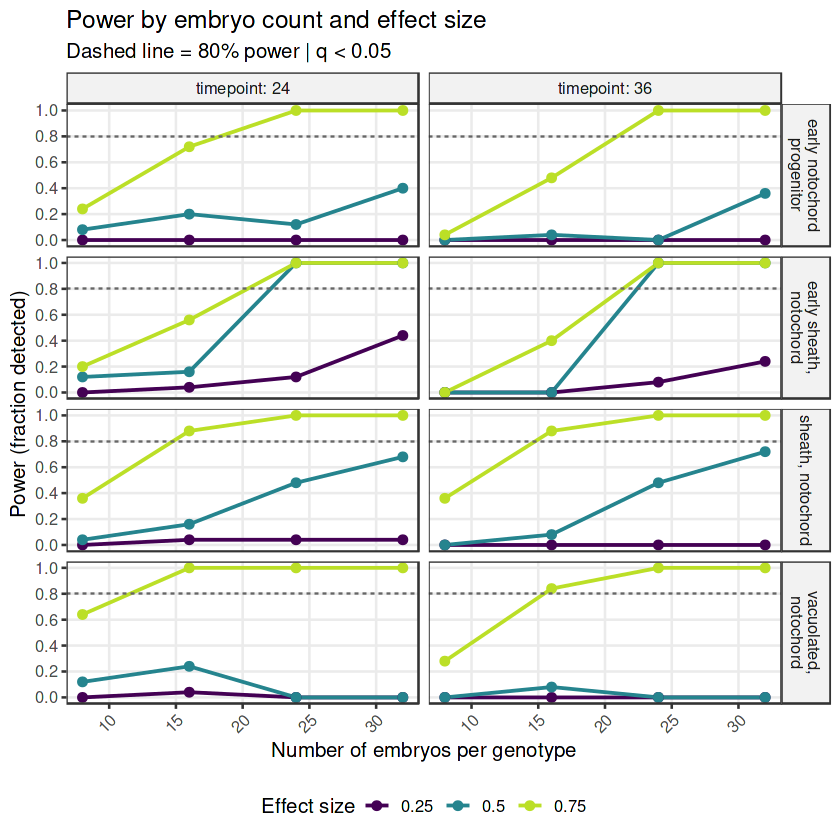

Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Warning message:
“Removed 153 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 153 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


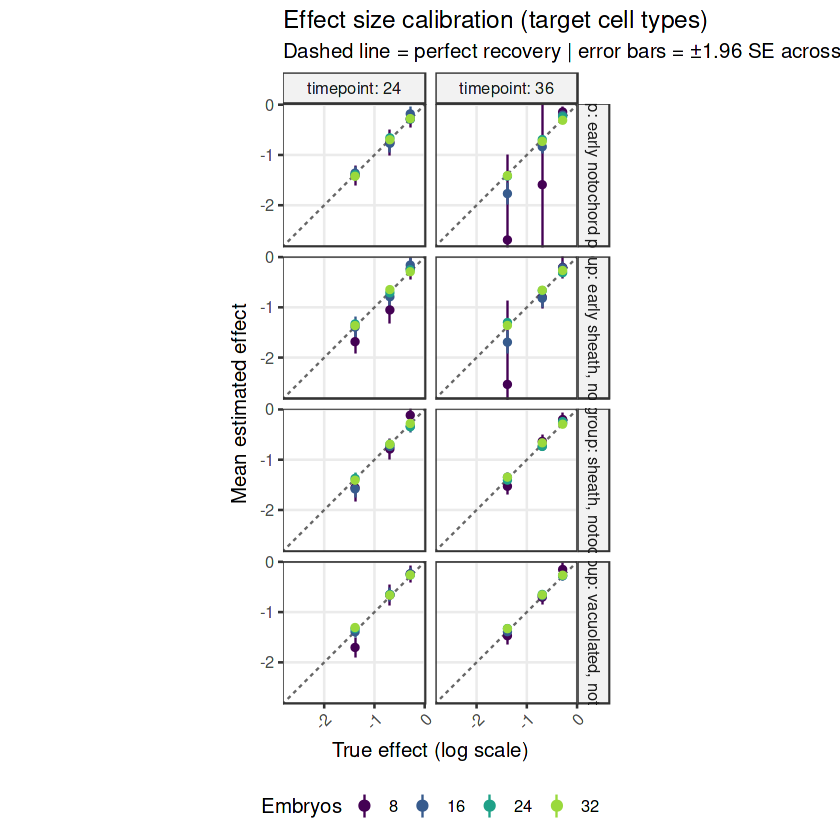

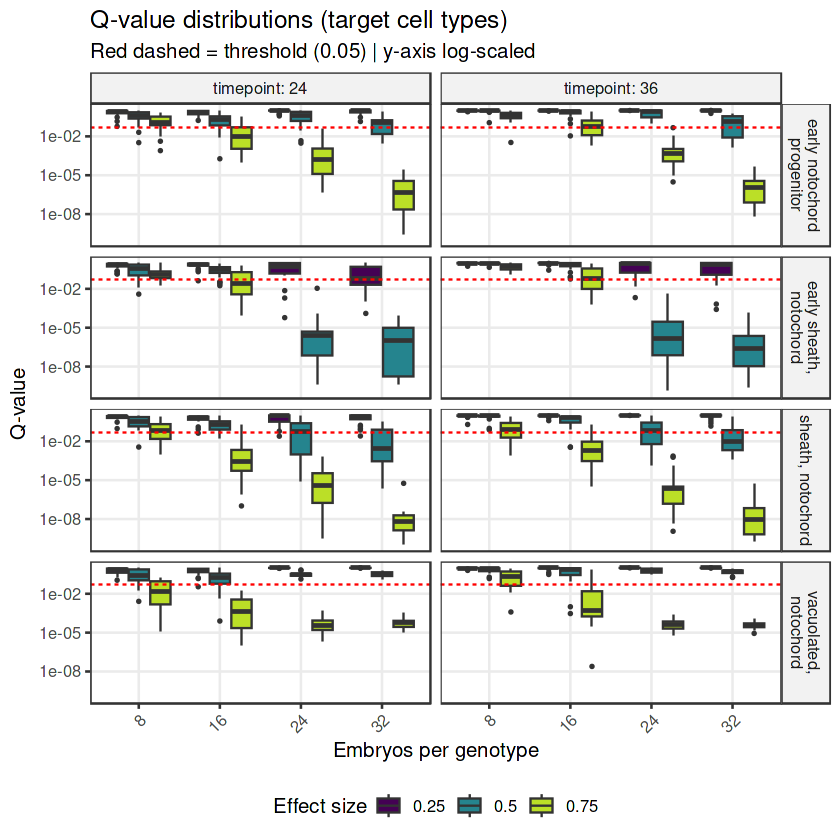

In [67]:
library(stringr)
# After running the NB GLM block (or PLN block), you have all_results_nb (or all_results)

# Power curves — the one you'll look at first
p1 <- plot_power_curves(all_results_nb, q_threshold = 0.05)  +
  facet_grid(cell_group ~ timepoint, labeller = labeller(
    cell_group = label_wrap_gen(width = 20),
    timepoint = label_both
    ))
ggsave("power_curves.pdf", p1, width = 10, height = 8)
print(p1)


# # Heatmap — quick overview of the parameter space
# p2 <- plot_power_heatmap(all_results_nb, q_threshold = 0.05)
# ggsave("power_heatmap.pdf", p2, width = 8, height = 6)

# # FPR — sanity check
# p3 <- plot_fpr(all_results_nb, q_threshold = 0.05)
# print(p3)

# Calibration — are your effect estimates attenuated?
p4 <- plot_calibration(all_results_nb)
ggsave("calibration.pdf", p4, width = 10, height = 8) +
  facet_grid(cell_group ~ timepoint, labeller = labeller(
    cell_group = label_wrap_gen(width = 20),
    timepoint = label_both
    ))
print(p4)


p5 <- plot_qvalue_distributions(all_results_nb, q_threshold = 0.05) + scale_y_log10(limits = c(1e-10, 1)) +
  facet_grid(cell_group ~ timepoint, labeller = labeller(
    cell_group = label_wrap_gen(width = 20),
    timepoint = label_both
    ))
ggsave("qvalue_distributions.pdf", p5, width = 10, height = 8)
print(p5)
# Compare PLN vs NB side by side if you ran both
# p1_pln <- plot_power_curves(all_results, q_threshold = 0.05) +
#   ggtitle("Power curves (PLN)")
# p1_nb <- plot_power_curves(all_results_nb, q_threshold = 0.05) +
#   ggtitle("Power curves (NB GLM)")

# library(patchwork)
# p1_pln + p1_nb

## Run Power Sweep (slow version) 

In [ ]:
run_trial <- function(ccs, target_cell_types, effect_size, num_embryos,
                      embryo_size, seed, q_threshold, num_threads,
                      timepoints = NULL, timepoint_col = "timepoint",
                      extra_cell_type_bootstrap_n = 0,
                      vhat_method = "bootstrap") {
  selected_timepoints <- get_timepoint_levels(
    ccs,
    timepoint_col = timepoint_col,
    timepoints = timepoints
  )

  wt_ccs <- simulate_ccs(
    ccs,
    embryo_size = embryo_size,
    num_embryos = num_embryos,
    random.seed = seed,
    genotype = "WT",
    timepoints = selected_timepoints,
    timepoint_col = timepoint_col
  )
  mt_ccs <- simulate_ccs(
    ccs,
    embryo_size = embryo_size,
    num_embryos = num_embryos,
    random.seed = seed + 1e6,
    genotype = "MT",
    timepoints = selected_timepoints,
    timepoint_col = timepoint_col
  )

  mutated_cell_types <- resolve_mutated_cell_types(
    mt_ccs,
    target_cell_types = target_cell_types,
    extra_cell_type_bootstrap_n = extra_cell_type_bootstrap_n,
    random.seed = seed + 2e6
  )
  mt_ccs <- mutate_ccs(mt_ccs, cell_types = mutated_cell_types,
                       effect_size = effect_size)

  combined <- combine_ccs(list(wt_ccs, mt_ccs))

  ccm <- tryCatch(
    new_cell_count_model(
      combined,
      main_model_formula_str = sprintf("~ genotype * %s", timepoint_col),
      penalize_by_distance   = FALSE,
      num_threads            = num_threads,
      vhat_method            = vhat_method
    ),
    error = function(e) NULL
  )

  if (is.null(ccm)) {
    return(tibble(
      timepoint = selected_timepoints,
      detected = NA,
      q_column = NA_character_,
      num_hits = NA_integer_,
      mutated_cell_types = paste(mutated_cell_types, collapse = "|")
    ))
  }

  dplyr::bind_rows(lapply(selected_timepoints, function(tp) {
    wt_newdata <- as.data.frame(
      stats::setNames(list("WT", tp), c("genotype", timepoint_col)),
      stringsAsFactors = FALSE
    )
    mt_newdata <- as.data.frame(
      stats::setNames(list("MT", tp), c("genotype", timepoint_col)),
      stringsAsFactors = FALSE
    )

    cond_wt <- estimate_abundances(ccm, wt_newdata)
    cond_mt <- estimate_abundances(ccm, mt_newdata)
    res <- compare_abundances(ccm, cond_wt, cond_mt)

    q_col <- if ("delta_q_value" %in% names(res)) "delta_q_value" else
      if ("delta_adj_p_value" %in% names(res)) "delta_adj_p_value" else
      if ("delta_p_value" %in% names(res)) "delta_p_value" else
      if ("q_value" %in% names(res)) "q_value" else
      if ("adj_p_value" %in% names(res)) "adj_p_value" else
      if ("p_value" %in% names(res)) "p_value" else NA_character_

    hits <- if (is.na(q_col)) {
      res[0, , drop = FALSE]
    } else {
      res %>% dplyr::filter(cell_group %in% target_cell_types, .data[[q_col]] < q_threshold)
    }

    tibble(
      timepoint = tp,
      detected = if (is.na(q_col)) NA else nrow(hits) > 0,
      q_column = q_col,
      num_hits = nrow(hits),
      mutated_cell_types = paste(mutated_cell_types, collapse = "|")
    )
  }))
}

grid <- expand.grid(
  effect_size = effect_sizes,
  num_embryos = embryo_counts,
  sim_idx     = seq_len(n_sim),
  stringsAsFactors = FALSE
)

n_trials <- nrow(grid)
cat(sprintf("Running %d total trials...\n", n_trials))

results <- vector("list", n_trials)
pb <- txtProgressBar(min = 0, max = n_trials, style = 3)
start_time <- Sys.time()

for (i in seq_len(n_trials)) {
  seed_i <- base_seed + i * 7

  results[[i]] <- run_trial(
    ccs               = ccs,
    target_cell_types = target_cell_types,
    effect_size       = grid$effect_size[i],
    num_embryos       = grid$num_embryos[i],
    embryo_size       = embryo_size,
    seed              = seed_i,
    q_threshold       = q_threshold,
    num_threads       = num_threads,
    timepoints        = sim_timepoints,
    timepoint_col     = timepoint_col,
    extra_cell_type_bootstrap_n = extra_cell_type_bootstrap_n,
    vhat_method       = vhat_method
  )

  results[[i]]$effect_size <- grid$effect_size[i]
  results[[i]]$num_embryos <- grid$num_embryos[i]
  results[[i]]$sim_idx <- grid$sim_idx[i]
  results[[i]]$seed <- seed_i

  setTxtProgressBar(pb, i)

  if (i %% 10 == 0 || i == n_trials) {
    elapsed <- as.numeric(difftime(Sys.time(), start_time, units = "secs"))
    avg_per_trial <- elapsed / i
    eta <- avg_per_trial * (n_trials - i)

    cat(sprintf(
      "\nCompleted %d/%d | elapsed: %.1f min | ETA: %.1f min\n",
      i, n_trials, elapsed / 60, eta / 60
    ))
  }
}

close(pb)
grid <- dplyr::bind_rows(results)
cat("\nDone.\n")

Running 320 total trials...
  |                                                                      |   0%

Warning message in monocle3::new_cell_data_set(sim_count_wide, cell_metadata = covariates_df):
“gene_metadata must contain a column verbatim named 'gene_short_name' for certain functions.”
Warning message in new_cell_data_set(hooke:::empty_sparse_matrix(format = "C")):
“gene_metadata must contain a column verbatim named 'gene_short_name' for certain functions.”
Warning message in monocle3::new_cell_data_set(sim_count_wide, cell_metadata = covariates_df):
“gene_metadata must contain a column verbatim named 'gene_short_name' for certain functions.”
Warning message in new_cell_data_set(hooke:::empty_sparse_matrix(format = "C")):
“gene_metadata must contain a column verbatim named 'gene_short_name' for certain functions.”
Warning message in monocle3::new_cell_data_set(sim_count_wide, cell_metadata = covariates_df):
“gene_metadata must contain a column verbatim named 'gene_short_name' for certain functions.”
Warning message in new_cell_data_set(hooke:::empty_sparse_matrix(format = "C")):
“g

## Summarize and Plot Power

In [ ]:
power_summary <- grid %>%
  filter(!is.na(detected)) %>%
  group_by(timepoint, effect_size, num_embryos) %>%
  summarise(
    power     = mean(detected),
    n_success = sum(detected),
    n_trials  = n(),
    .groups   = "drop"
  )

print(power_summary)

In [ ]:
power_summary$num_embryos_f <- factor(power_summary$num_embryos)

ggplot(power_summary, aes(x = effect_size * 100, y = power,
                          color = num_embryos_f, group = num_embryos_f)) +
  geom_line(linewidth = 0.9) +
  geom_point(size = 3) +
  facet_wrap(~ timepoint) +
  geom_hline(yintercept = 0.80, linetype = "dashed", color = "grey40") +
  scale_y_continuous(limits = c(0, 1), labels = scales::percent) +
  scale_x_continuous(breaks = effect_sizes * 100,
                     labels = paste0(effect_sizes * 100, "%")) +
  labs(
    title    = paste("Power to detect reduction in:",
                     paste(target_cell_types, collapse = ", ")),
    subtitle = sprintf("%d simulations per grid cell | embryo_size = %d | q < %.2f | extra bootstrap cell types = %d",
                       n_sim, embryo_size, q_threshold, extra_cell_type_bootstrap_n),
    x        = "Effect size (% reduction in target cell type)",
    y        = "Power (fraction of simulations detected)",
    color    = "Embryos per arm"
  ) +
  theme_bw(base_size = 14)

## Optional: Save Results

In [ ]:
out_csv <- file.path(
  ".",
  paste0("power_results_",
         paste(gsub(" ", "_", target_cell_types), collapse = "_"),
         ".csv")
)
write.csv(power_summary, out_csv, row.names = FALSE)
cat("Saved to", out_csv, "\n")